In [68]:
import numpy as np
import matplotlib.pyplot as plt

from simpulse.sim.model import Spectra, fgrid
from simpulse.io.sigproc import SigprocFile
from simpulse.sim.measurement import L2_clean

Actual SNR: 1153.6448705400733


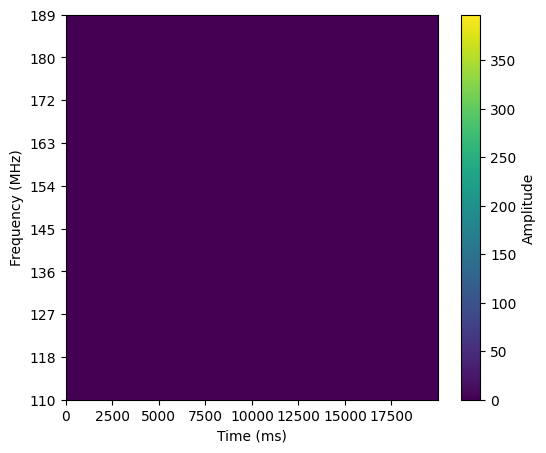

In [74]:
spec = Spectra(
    fch1=110,           
    nchan=3096,         
    bwchan=0.0258,      
    tsamp=1,            
    fbin=10,            
    tbin=10             
)

# Simple pulse with 0 DM (no dispersion)
pulse_orig, _ = spec.burst(
    t0=20000,
    width=10,
    A=10000,
    mode='single',
    dm=0,
    nsamp=20000
)


# noise = np.random.normal(50, 10, pulse.shape)
# plt.hist(noise.flatten(), bins=50, alpha=0.7, label='Noise')
# plt.show()

pulse = pulse_orig.T
actual_snr = L2_clean(pulse)
print(f"Actual SNR: {actual_snr}")


# Plot

# pulse = pulse[::-1, :] 
# data = pulse.astype(np.float32)

ytick_indices = np.linspace(0, spec.nchan-1, 10, dtype=int)
# flip y-ticks to match flipped pulse
ytick_freqs = spec.vif[ytick_indices]
# invert y-ticks 
ytick_freqs = ytick_freqs[::-1]
plt.figure(figsize=(6, 5))
plt.imshow(pulse, aspect='auto', cmap='viridis')
plt.yticks(ytick_indices, ytick_freqs.astype(int))  
plt.ylabel('Frequency (MHz)')
plt.xlabel('Time (ms)')
plt.colorbar(label='Amplitude')
plt.show()

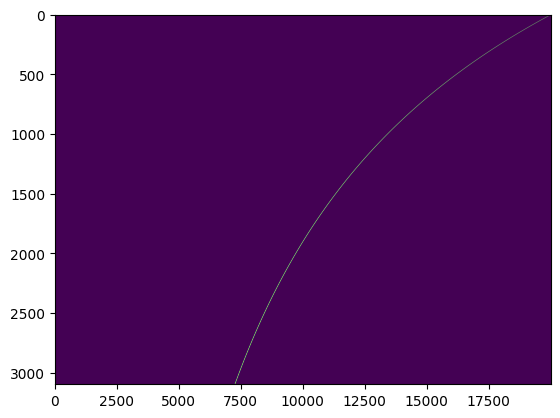

In [81]:
pulse_orig, _ = spec.burst(
    t0=20000,
    width=10,
    A=10000,
    mode='single',
    dm=56,
    nsamp=20000
)

# Add an array full of 5's 
zeros = np.full_like(pulse_orig, 5)
pulse_to_write = zeros + pulse_orig

# For plotting (transpose as before)
pulse = pulse_orig.T
plt.imshow(pulse, aspect='auto', cmap='viridis')

# For writing (keep original orientation)
header = {
    'source_name': 'test_pulse',
    'machine_id': 0,
    'telescope_id': 0,
    'data_type': 1,
    'nbits': 32,
    'nchans': spec.nchan,
    'nifs': 1,
    'nsamples': pulse_to_write.shape[0],
    'tsamp': spec.tsamp / 1000,
    'fch1': spec.fch1,
    'foff': spec.bwchan,
    'tstart': 59000.0,
}

sigproc_file = SigprocFile('output.fil', mode='w', header=header)
data = pulse_to_write.astype(np.float32)
sigproc_file.fin.write(data.tobytes())
sigproc_file.fin.close()